In [2]:
!pip -q install tenseal flwr ucimlrepo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.2/926.2 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.4/25.4 MB 60.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==

In [ ]:
import tenseal as ts
import flwr as fl
from ucimlrepo import fetch_ucirepo

print("TenSEAL imported successfully")
print("Flower imported successfully")
print("UCI ML Repo imported successfully")


TenSEAL imported successfully
Flower imported successfully
UCI ML Repo imported successfully


In [3]:
import time
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tenseal as ts
import flwr as fl

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_CLIENTS = 3
N_ROUNDS = 5

print("Libraries loaded successfully")
print("Python version:", sys.version)
print("Flower version:", fl.__version__)


Libraries loaded successfully
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Flower version: 1.31.0


In [6]:
!pip -q install tenseal flwr ucimlrepo

import time
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tenseal as ts
import flwr as fl

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_CLIENTS = 3
N_ROUNDS = 5

print("Setup completed successfully")

Setup completed successfully


In [ ]:
!pip -q install kagglehub


In [14]:
import kagglehub
import os
import glob

dataset_path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Dataset folder:", dataset_path)
print("Files found:", glob.glob(os.path.join(dataset_path, "*")))

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Dataset folder: /kaggle/input/stroke-prediction-dataset
Files found: ['/kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv']


In [15]:
stroke_file = glob.glob(
    os.path.join(dataset_path, "healthcare-dataset-stroke-data.csv")
)[0]

stroke_data = pd.read_csv(stroke_file)

print(stroke_data.head())
print(stroke_data.shape)

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  
(5110, 12)


In [16]:
# Preprocess Stroke Prediction dataset

# Remove ID column
stroke_data = stroke_data.drop(columns=["id"])

# Remove rows with missing BMI values
stroke_data = stroke_data.dropna().copy()

# Separate target and features
y = stroke_data["stroke"].astype(int)
X = stroke_data.drop(columns=["stroke"])

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Ensure all columns are numeric
X = X.astype(float)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Stroke dataset preprocessed successfully")
print("Total cleaned samples:", len(stroke_data))
print("Training samples:", X_train_scaled.shape[0])
print("Test samples:", X_test_scaled.shape[0])
print("Number of features:", X_train_scaled.shape[1])

print("\nOverall class distribution:")
print(y.value_counts())

print("\nTraining class distribution:")
print(y_train.value_counts())

Stroke dataset preprocessed successfully
Total cleaned samples: 4909
Training samples: 3927
Test samples: 982
Number of features: 16

Overall class distribution:
stroke
0    4700
1     209
Name: count, dtype: int64

Training class distribution:
stroke
0    3760
1     167
Name: count, dtype: int64


In [17]:
# Centralised Logistic Regression baseline for Stroke Prediction

central_start = time.time()

central_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    solver="liblinear"
)

central_model.fit(X_train_scaled, y_train)

central_training_time = time.time() - central_start

central_infer_start = time.time()

central_pred = central_model.predict(X_test_scaled)
central_prob = central_model.predict_proba(X_test_scaled)[:, 1]

central_inference_time = time.time() - central_infer_start

central_metrics = {
    "method": "Centralised Logistic Regression",
    "accuracy": accuracy_score(y_test, central_pred),
    "precision": precision_score(y_test, central_pred, zero_division=0),
    "recall": recall_score(y_test, central_pred, zero_division=0),
    "f1_score": f1_score(y_test, central_pred, zero_division=0),
    "balanced_accuracy": balanced_accuracy_score(y_test, central_pred),
    "roc_auc": roc_auc_score(y_test, central_prob),
    "training_time_seconds": central_training_time,
    "inference_time_seconds": central_inference_time,
}

print("Centralised Stroke baseline completed")
for key, value in central_metrics.items():
    print(f"{key}: {value}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, central_pred))

Centralised Stroke baseline completed
method: Centralised Logistic Regression
accuracy: 0.7566191446028513
precision: 0.11372549019607843
recall: 0.6904761904761905
f1_score: 0.19528619528619529
balanced_accuracy: 0.7250253292806484
roc_auc: 0.810258358662614
training_time_seconds: 0.04959273338317871
inference_time_seconds: 0.0038352012634277344

Confusion matrix:
[[714 226]
 [ 13  29]]


In [18]:
# Create three simulated hospitals from the Stroke training data
# Stratification ensures each hospital has stroke-positive cases.

X_hosp_a, X_remaining, y_hosp_a, y_remaining = train_test_split(
    X_train_scaled,
    y_train.to_numpy(),
    train_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y_train
)

# Split remaining 60% into 35% and 25% of original training data
hospital_b_fraction = 35 / 60

X_hosp_b, X_hosp_c, y_hosp_b, y_hosp_c = train_test_split(
    X_remaining,
    y_remaining,
    train_size=hospital_b_fraction,
    random_state=RANDOM_STATE,
    stratify=y_remaining
)

hospital_data = {
    "Hospital_A": (X_hosp_a, y_hosp_a),
    "Hospital_B": (X_hosp_b, y_hosp_b),
    "Hospital_C": (X_hosp_c, y_hosp_c),
}

for hospital_name, (X_hospital, y_hospital) in hospital_data.items():
    print(f"\n{hospital_name}")
    print("Samples:", len(y_hospital))
    print("Class distribution [no stroke, stroke]:", np.bincount(y_hospital))


Hospital_A
Samples: 1570
Class distribution [no stroke, stroke]: [1503   67]

Hospital_B
Samples: 1374
Class distribution [no stroke, stroke]: [1316   58]

Hospital_C
Samples: 983
Class distribution [no stroke, stroke]: [941  42]


In [ ]:
# Centralised Logistic Regression baseline

central_start = time.time()

central_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

central_model.fit(X_train_scaled, y_train)

central_training_time = time.time() - central_start

central_infer_start = time.time()

central_pred = central_model.predict(X_test_scaled)
central_prob = central_model.predict_proba(X_test_scaled)[:, 1]

central_inference_time = time.time() - central_infer_start

central_metrics = {
    "method": "Centralised Logistic Regression",
    "accuracy": accuracy_score(y_test, central_pred),
    "precision": precision_score(y_test, central_pred),
    "recall": recall_score(y_test, central_pred),
    "f1_score": f1_score(y_test, central_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, central_pred),
    "roc_auc": roc_auc_score(y_test, central_prob),
    "training_time_seconds": central_training_time,
    "inference_time_seconds": central_inference_time,
}

print("Centralised baseline completed")
for k, v in central_metrics.items():
    print(f"{k}: {v}")
print("Confusion matrix:")
print(confusion_matrix(y_test, central_pred))

Centralised baseline completed
method: Centralised Logistic Regression
accuracy: 0.8333333333333334
precision: 0.8461538461538461
recall: 0.7857142857142857
f1_score: 0.8148148148148148
balanced_accuracy: 0.8303571428571428
roc_auc: 0.9497767857142857
training_time_seconds: 0.00494694709777832
inference_time_seconds: 0.0010232925415039062
Confusion matrix:
[[28  4]
 [ 6 22]]


In [ ]:
# Create three simulated hospitals from the training set
# Stratified split ensures each hospital receives both classes.

X_hosp_a, X_remaining, y_hosp_a, y_remaining = train_test_split(
    X_train_scaled,
    y_train.to_numpy(),
    train_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y_train
)

# Of the remaining 60%, allocate 35/60 to Hospital B and 25/60 to Hospital C
hospital_b_fraction = 35 / 60

X_hosp_b, X_hosp_c, y_hosp_b, y_hosp_c = train_test_split(
    X_remaining,
    y_remaining,
    train_size=hospital_b_fraction,
    random_state=RANDOM_STATE,
    stratify=y_remaining
)

hospital_data = {
    "Hospital_A": (X_hosp_a, y_hosp_a),
    "Hospital_B": (X_hosp_b, y_hosp_b),
    "Hospital_C": (X_hosp_c, y_hosp_c),
}

for hospital_name, (X_hospital, y_hospital) in hospital_data.items():
    print(f"\n{hospital_name}")
    print("Samples:", len(y_hospital))
    print("Class distribution:", np.bincount(y_hospital))


Hospital_A
Samples: 94
Class distribution: [51 43]

Hospital_B
Samples: 83
Class distribution: [45 38]

Hospital_C
Samples: 60
Class distribution: [32 28]


In [ ]:
def get_model_parameters(model):
    return [
        model.coef_.copy(),
        model.intercept_.copy()
    ]


def set_model_parameters(model, parameters):
    model.coef_ = parameters[0].copy()
    model.intercept_ = parameters[1].copy()
    model.classes_ = np.array([0, 1])
    return model


def weighted_average_parameters(client_parameters, client_sizes):
    total_size = sum(client_sizes)

    avg_coef = sum(
        params[0] * size for params, size in zip(client_parameters, client_sizes)
    ) / total_size

    avg_intercept = sum(
        params[1] * size for params, size in zip(client_parameters, client_sizes)
    ) / total_size

    return [avg_coef, avg_intercept]


print("Federated parameter helper functions ready")

Federated parameter helper functions ready


In [ ]:
# Manual FedAvg simulation using three hospital clients

def train_local_model(X_local, y_local, initial_parameters=None):
    local_model = LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    )

    # LogisticRegression needs fitting before parameters can be set reliably.
    local_model.fit(X_local, y_local)

    if initial_parameters is not None:
        local_model = set_model_parameters(local_model, initial_parameters)
        local_model.fit(X_local, y_local)

    return local_model


fed_start = time.time()

# Initialise global model using a small central fit
global_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)
global_model.fit(X_train_scaled, y_train)

global_parameters = get_model_parameters(global_model)

round_logs = []

for round_id in range(1, N_ROUNDS + 1):
    client_parameters = []
    client_sizes = []
    local_times = []

    for hospital_name, (X_local, y_local) in hospital_data.items():
        local_start = time.time()

        local_model = train_local_model(
            X_local,
            y_local,
            initial_parameters=global_parameters
        )

        local_time = time.time() - local_start

        client_parameters.append(get_model_parameters(local_model))
        client_sizes.append(len(y_local))
        local_times.append(local_time)

    global_parameters = weighted_average_parameters(client_parameters, client_sizes)
    global_model = set_model_parameters(global_model, global_parameters)

    fed_pred = global_model.predict(X_test_scaled)
    fed_prob = global_model.predict_proba(X_test_scaled)[:, 1]

    round_logs.append({
        "round": round_id,
        "mean_local_training_time_seconds": np.mean(local_times),
        "aggregation_time_seconds": 0.0,
        "accuracy": accuracy_score(y_test, fed_pred),
        "precision": precision_score(y_test, fed_pred),
        "recall": recall_score(y_test, fed_pred),
        "f1_score": f1_score(y_test, fed_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, fed_pred),
        "roc_auc": roc_auc_score(y_test, fed_prob),
    })

fed_total_time = time.time() - fed_start

fed_metrics = round_logs[-1].copy()
fed_metrics["method"] = "Federated Logistic Regression FedAvg"
fed_metrics["total_training_time_seconds"] = fed_total_time

print("Federated learning simulation completed")
print("Final round metrics:")
for k, v in fed_metrics.items():
    print(f"{k}: {v}")

print("\nRound logs:")
display(pd.DataFrame(round_logs))

Federated learning simulation completed
Final round metrics:
round: 5
mean_local_training_time_seconds: 0.09042080243428548
aggregation_time_seconds: 0.0
accuracy: 0.8333333333333334
precision: 0.8461538461538461
recall: 0.7857142857142857
f1_score: 0.8148148148148148
balanced_accuracy: 0.8303571428571428
roc_auc: 0.9441964285714286
method: Federated Logistic Regression FedAvg
total_training_time_seconds: 1.3627219200134277

Round logs:


,round,mean_local_training_time_seconds,aggregation_time_seconds,accuracy,precision,recall,f1_score,balanced_accuracy,roc_auc
0,1,0.022313,0.0,0.833333,0.846154,0.785714,0.814815,0.830357,0.944196
1,2,0.081345,0.0,0.833333,0.846154,0.785714,0.814815,0.830357,0.944196
2,3,0.082876,0.0,0.833333,0.846154,0.785714,0.814815,0.830357,0.944196
3,4,0.090853,0.0,0.833333,0.846154,0.785714,0.814815,0.830357,0.944196
4,5,0.090421,0.0,0.833333,0.846154,0.785714,0.814815,0.830357,0.944196


In [19]:
LOCAL_EPOCHS = 5
LEARNING_RATE = 0.01
CLASSES = np.array([0, 1])

# Give the minority stroke class a higher training weight
negative_count = np.sum(y_train.to_numpy() == 0)
positive_count = np.sum(y_train.to_numpy() == 1)

stroke_class_weights = {
    0: 1.0,
    1: negative_count / positive_count
}

print("Stroke class weights:", stroke_class_weights)


def initialise_sgd_model(n_features):
    model = SGDClassifier(
        loss="log_loss",
        learning_rate="constant",
        eta0=LEARNING_RATE,
        alpha=0.0001,
        max_iter=1,
        tol=None,
        random_state=RANDOM_STATE,
        fit_intercept=True,
    )

    # Initialise internal model attributes and parameter shapes
    model.partial_fit(
        np.zeros((1, n_features)),
        np.array([0]),
        classes=CLASSES
    )
    return model


def get_sgd_parameters(model):
    return [model.coef_.copy(), model.intercept_.copy()]


def set_sgd_parameters(model, parameters):
    model.coef_ = parameters[0].copy()
    model.intercept_ = parameters[1].copy()
    model.classes_ = CLASSES
    return model


def weighted_average_parameters(client_parameters, client_sizes):
    total_size = sum(client_sizes)

    avg_coef = sum(
        params[0] * size for params, size in zip(client_parameters, client_sizes)
    ) / total_size

    avg_intercept = sum(
        params[1] * size for params, size in zip(client_parameters, client_sizes)
    ) / total_size

    return [avg_coef, avg_intercept]


def train_local_sgd_model(X_local, y_local, global_parameters):
    local_model = initialise_sgd_model(X_local.shape[1])
    local_model = set_sgd_parameters(local_model, global_parameters)

    # Assign larger sample weights to stroke-positive records
    sample_weights = np.where(
        y_local == 1,
        stroke_class_weights[1],
        stroke_class_weights[0]
    )

    local_start = time.time()

    for _ in range(LOCAL_EPOCHS):
        local_model.partial_fit(
            X_local,
            y_local,
            classes=CLASSES,
            sample_weight=sample_weights
        )

    local_training_time = time.time() - local_start
    return local_model, local_training_time


print("Stroke federated-learning helper functions ready")

Stroke class weights: {0: 1.0, 1: np.float64(22.51497005988024)}
Stroke federated-learning helper functions ready


In [20]:
# Proper FedAvg simulation for the Stroke dataset
# Uses the three simulated hospitals and class-weighted local training.

fedavg_start = time.time()

# Create the initial global model
global_fedavg_model = initialise_sgd_model(X_train_scaled.shape[1])
global_fedavg_parameters = get_sgd_parameters(global_fedavg_model)

fedavg_round_logs = []

for round_id in range(1, N_ROUNDS + 1):
    client_parameters = []
    client_sizes = []
    local_times = []

    # Each hospital trains locally from the current global model
    for hospital_name, (X_local, y_local) in hospital_data.items():
        local_model, local_time = train_local_sgd_model(
            X_local,
            y_local,
            global_fedavg_parameters
        )

        client_parameters.append(get_sgd_parameters(local_model))
        client_sizes.append(len(y_local))
        local_times.append(local_time)

    # Server aggregates the hospital models using FedAvg
    aggregation_start = time.time()

    global_fedavg_parameters = weighted_average_parameters(
        client_parameters,
        client_sizes
    )

    aggregation_time = time.time() - aggregation_start

    # Update global model with aggregated parameters
    global_fedavg_model = set_sgd_parameters(
        global_fedavg_model,
        global_fedavg_parameters
    )

    # Evaluate global federated model on the held-out test set
    fedavg_pred = global_fedavg_model.predict(X_test_scaled)
    fedavg_prob = global_fedavg_model.predict_proba(X_test_scaled)[:, 1]

    fedavg_round_logs.append({
        "round": round_id,
        "mean_local_training_time_seconds": np.mean(local_times),
        "aggregation_time_seconds": aggregation_time,
        "accuracy": accuracy_score(y_test, fedavg_pred),
        "precision": precision_score(y_test, fedavg_pred, zero_division=0),
        "recall": recall_score(y_test, fedavg_pred, zero_division=0),
        "f1_score": f1_score(y_test, fedavg_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, fedavg_pred),
        "roc_auc": roc_auc_score(y_test, fedavg_prob),
    })

fedavg_total_training_time = time.time() - fedavg_start

fedavg_metrics = fedavg_round_logs[-1].copy()
fedavg_metrics["method"] = "Federated Logistic Regression (FedAvg)"
fedavg_metrics["total_training_time_seconds"] = fedavg_total_training_time

print("Stroke FedAvg simulation completed")
print("\nFinal-round metrics:")
for key, value in fedavg_metrics.items():
    print(f"{key}: {value}")

print("\nFinal confusion matrix:")
print(confusion_matrix(y_test, fedavg_pred))

print("\nRound-by-round results:")
display(pd.DataFrame(fedavg_round_logs))

Stroke FedAvg simulation completed

Final-round metrics:
round: 5
mean_local_training_time_seconds: 0.00970760981241862
aggregation_time_seconds: 5.7697296142578125e-05
accuracy: 0.7464358452138493
precision: 0.10344827586206896
recall: 0.6428571428571429
f1_score: 0.1782178217821782
balanced_accuracy: 0.6969604863221885
roc_auc: 0.8101317122593719
method: Federated Logistic Regression (FedAvg)
total_training_time_seconds: 0.2990102767944336

Final confusion matrix:
[[706 234]
 [ 15  27]]

Round-by-round results:


,round,mean_local_training_time_seconds,aggregation_time_seconds,accuracy,precision,recall,f1_score,balanced_accuracy,roc_auc
0,1,0.009396,0.000108,0.748473,0.104247,0.642857,0.179402,0.698024,0.810157
1,2,0.009619,0.000061,0.745418,0.103053,0.642857,0.177632,0.696429,0.810182
2,3,0.012811,0.000055,0.746436,0.103448,0.642857,0.178218,0.696960,0.810132
3,4,0.011318,0.000059,0.746436,0.103448,0.642857,0.178218,0.696960,0.810106
4,5,0.009708,0.000058,0.746436,0.103448,0.642857,0.178218,0.696960,0.810132


In [21]:
# Estimate federated communication overhead for Stroke

def parameter_size_bytes(parameters):
    return sum(param.nbytes for param in parameters)

global_model_size_bytes = parameter_size_bytes(global_fedavg_parameters)

# Each client downloads the global model and uploads its local update in every round
fl_upload_bytes = global_model_size_bytes * N_CLIENTS * N_ROUNDS
fl_download_bytes = global_model_size_bytes * N_CLIENTS * N_ROUNDS
fl_total_communication_bytes = fl_upload_bytes + fl_download_bytes

communication_metrics = {
    "method": "Federated Learning (FedAvg)",
    "model_parameter_size_bytes": global_model_size_bytes,
    "model_parameter_size_kb": global_model_size_bytes / 1024,
    "number_of_clients": N_CLIENTS,
    "number_of_rounds": N_ROUNDS,
    "upload_bytes": fl_upload_bytes,
    "download_bytes": fl_download_bytes,
    "total_communication_bytes": fl_total_communication_bytes,
    "total_communication_kb": fl_total_communication_bytes / 1024,
}

print("Stroke federated communication overhead:")
for key, value in communication_metrics.items():
    print(f"{key}: {value}")

Stroke federated communication overhead:
method: Federated Learning (FedAvg)
model_parameter_size_bytes: 136
model_parameter_size_kb: 0.1328125
number_of_clients: 3
number_of_rounds: 5
upload_bytes: 2040
download_bytes: 2040
total_communication_bytes: 4080
total_communication_kb: 3.984375


In [22]:
# CKKS encrypted inference for the Stroke test set

# Extract parameters from the trained centralised model
weights = central_model.coef_[0].astype(float)
bias = float(central_model.intercept_[0])

# Create CKKS context
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)
context.global_scale = 2**40
context.generate_galois_keys()

# Measure encrypted-query size using one representative test sample
sample_vector = ts.ckks_vector(context, X_test_scaled[0].tolist())
ckks_ciphertext_size_bytes = len(sample_vector.serialize())

encryption_times = []
encrypted_inference_times = []
decryption_times = []
encrypted_scores = []

for index, row in enumerate(X_test_scaled):
    encryption_start = time.time()
    enc_x = ts.ckks_vector(context, row.tolist())
    encryption_times.append(time.time() - encryption_start)

    encrypted_inference_start = time.time()
    enc_score = enc_x.dot(weights.tolist()) + bias
    encrypted_inference_times.append(time.time() - encrypted_inference_start)

    decryption_start = time.time()
    decrypted_score = enc_score.decrypt()[0]
    decryption_times.append(time.time() - decryption_start)

    encrypted_scores.append(decrypted_score)

    # Progress indicator every 100 records
    if (index + 1) % 100 == 0:
        print(f"Processed {index + 1} of {len(X_test_scaled)} test records")

encrypted_scores = np.array(encrypted_scores)

# Convert encrypted linear scores to logistic-regression probabilities
encrypted_prob = 1 / (1 + np.exp(-encrypted_scores))
encrypted_pred = (encrypted_prob >= 0.5).astype(int)

ckks_metrics = {
    "method": "CKKS Encrypted Inference",
    "accuracy": accuracy_score(y_test, encrypted_pred),
    "precision": precision_score(y_test, encrypted_pred, zero_division=0),
    "recall": recall_score(y_test, encrypted_pred, zero_division=0),
    "f1_score": f1_score(y_test, encrypted_pred, zero_division=0),
    "balanced_accuracy": balanced_accuracy_score(y_test, encrypted_pred),
    "roc_auc": roc_auc_score(y_test, encrypted_prob),
    "average_encryption_time_seconds": np.mean(encryption_times),
    "average_encrypted_inference_time_seconds": np.mean(encrypted_inference_times),
    "average_decryption_time_seconds": np.mean(decryption_times),
    "average_total_time_seconds": (
        np.mean(encryption_times)
        + np.mean(encrypted_inference_times)
        + np.mean(decryption_times)
    ),
    "ciphertext_size_bytes_per_query": ckks_ciphertext_size_bytes,
    "ciphertext_size_kb_per_query": ckks_ciphertext_size_bytes / 1024,
}

print("\nCKKS encrypted Stroke inference completed")
for key, value in ckks_metrics.items():
    print(f"{key}: {value}")

print("\nEncrypted confusion matrix:")
print(confusion_matrix(y_test, encrypted_pred))

# Numerical agreement against the plaintext linear score
plaintext_scores = central_model.decision_function(X_test_scaled)
mean_absolute_score_error = np.mean(np.abs(plaintext_scores - encrypted_scores))
max_absolute_score_error = np.max(np.abs(plaintext_scores - encrypted_scores))

print("\nNumerical agreement:")
print("Mean absolute score error:", mean_absolute_score_error)
print("Max absolute score error:", max_absolute_score_error)

Processed 100 of 982 test records
Processed 200 of 982 test records
Processed 300 of 982 test records
Processed 400 of 982 test records
Processed 500 of 982 test records
Processed 600 of 982 test records
Processed 700 of 982 test records
Processed 800 of 982 test records
Processed 900 of 982 test records

CKKS encrypted Stroke inference completed
method: CKKS Encrypted Inference
accuracy: 0.7566191446028513
precision: 0.11372549019607843
recall: 0.6904761904761905
f1_score: 0.19528619528619529
balanced_accuracy: 0.7250253292806484
roc_auc: 0.810258358662614
average_encryption_time_seconds: 0.010977631188215889
average_encrypted_inference_time_seconds: 0.020317779539073315
average_decryption_time_seconds: 0.002072929364843427
average_total_time_seconds: 0.03336834009213263
ciphertext_size_bytes_per_query: 334445
ciphertext_size_kb_per_query: 326.6064453125

Encrypted confusion matrix:
[[714 226]
 [ 13  29]]

Numerical agreement:
Mean absolute score error: 4.2262861917694464e-07
Max abso

In [23]:
# Consolidate Stroke results

stroke_performance_results = pd.DataFrame([
    {
        "Method": "Centralised LR",
        "Accuracy": central_metrics["accuracy"],
        "Precision": central_metrics["precision"],
        "Recall": central_metrics["recall"],
        "F1-score": central_metrics["f1_score"],
        "Balanced Accuracy": central_metrics["balanced_accuracy"],
        "ROC-AUC": central_metrics["roc_auc"],
    },
    {
        "Method": "Federated LR (FedAvg)",
        "Accuracy": fedavg_metrics["accuracy"],
        "Precision": fedavg_metrics["precision"],
        "Recall": fedavg_metrics["recall"],
        "F1-score": fedavg_metrics["f1_score"],
        "Balanced Accuracy": fedavg_metrics["balanced_accuracy"],
        "ROC-AUC": fedavg_metrics["roc_auc"],
    },
    {
        "Method": "CKKS Encrypted Inference",
        "Accuracy": ckks_metrics["accuracy"],
        "Precision": ckks_metrics["precision"],
        "Recall": ckks_metrics["recall"],
        "F1-score": ckks_metrics["f1_score"],
        "Balanced Accuracy": ckks_metrics["balanced_accuracy"],
        "ROC-AUC": ckks_metrics["roc_auc"],
    },
])

stroke_runtime_results = pd.DataFrame([
    {
        "Method": "Centralised LR",
        "Training Time (s)": central_metrics["training_time_seconds"],
        "Inference Time (s)": central_metrics["inference_time_seconds"],
        "Encryption Time per Query (s)": np.nan,
        "Decryption Time per Query (s)": np.nan,
        "Total Time per Query (s)": np.nan,
    },
    {
        "Method": "Federated LR (FedAvg)",
        "Training Time (s)": fedavg_metrics["total_training_time_seconds"],
        "Inference Time (s)": np.nan,
        "Encryption Time per Query (s)": np.nan,
        "Decryption Time per Query (s)": np.nan,
        "Total Time per Query (s)": np.nan,
    },
    {
        "Method": "CKKS Encrypted Inference",
        "Training Time (s)": np.nan,
        "Inference Time (s)": ckks_metrics["average_encrypted_inference_time_seconds"],
        "Encryption Time per Query (s)": ckks_metrics["average_encryption_time_seconds"],
        "Decryption Time per Query (s)": ckks_metrics["average_decryption_time_seconds"],
        "Total Time per Query (s)": ckks_metrics["average_total_time_seconds"],
    },
])

stroke_communication_results = pd.DataFrame([
    {
        "Method": "Federated LR (FedAvg)",
        "Communication Phase": "Training (5 rounds, 3 hospitals)",
        "Communication Bytes": communication_metrics["total_communication_bytes"],
        "Communication KB": communication_metrics["total_communication_kb"],
    },
    {
        "Method": "CKKS Encrypted Inference",
        "Communication Phase": "Per encrypted inference query",
        "Communication Bytes": ckks_metrics["ciphertext_size_bytes_per_query"],
        "Communication KB": ckks_metrics["ciphertext_size_kb_per_query"],
    },
])

print("Stroke performance results")
display(stroke_performance_results.round(4))

print("Stroke runtime results")
display(stroke_runtime_results.round(6))

print("Stroke communication results")
display(stroke_communication_results.round(4))

Stroke performance results


,Method,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,ROC-AUC
0,Centralised LR,0.7566,0.1137,0.6905,0.1953,0.725,0.8103
1,Federated LR (FedAvg),0.7464,0.1034,0.6429,0.1782,0.697,0.8101
2,CKKS Encrypted Inference,0.7566,0.1137,0.6905,0.1953,0.725,0.8103


Stroke runtime results


,Method,Training Time (s),Inference Time (s),Encryption Time per Query (s),Decryption Time per Query (s),Total Time per Query (s)
0,Centralised LR,0.049593,0.003835,NaN,NaN,NaN
1,Federated LR (FedAvg),0.299010,NaN,NaN,NaN,NaN
2,CKKS Encrypted Inference,NaN,0.020318,0.010978,0.002073,0.033368


Stroke communication results


,Method,Communication Phase,Communication Bytes,Communication KB
0,Federated LR (FedAvg),"Training (5 rounds, 3 hospitals)",4080,3.9844
1,CKKS Encrypted Inference,Per encrypted inference query,334445,326.6064


In [24]:
# Save Stroke results as CSV files

stroke_performance_results.to_csv(
    "stroke_performance_results.csv",
    index=False
)

stroke_runtime_results.to_csv(
    "stroke_runtime_results.csv",
    index=False
)

stroke_communication_results.to_csv(
    "stroke_communication_results.csv",
    index=False
)

stroke_fedavg_round_results = pd.DataFrame(fedavg_round_logs)
stroke_fedavg_round_results.to_csv(
    "stroke_fedavg_round_results.csv",
    index=False
)

print("CSV files saved successfully:")
print("- stroke_performance_results.csv")
print("- stroke_runtime_results.csv")
print("- stroke_communication_results.csv")
print("- stroke_fedavg_round_results.csv")

CSV files saved successfully:
- stroke_performance_results.csv
- stroke_runtime_results.csv
- stroke_communication_results.csv
- stroke_fedavg_round_results.csv


In [ ]:
# Estimate federated communication overhead
# Each client uploads model parameters and downloads the global model once per round.

def parameter_size_bytes(parameters):
    return sum(param.nbytes for param in parameters)


global_model_size_bytes = parameter_size_bytes(global_fedavg_parameters)

# Per round:
# Each of 3 clients downloads the global model and uploads its updated model.
fl_upload_bytes = global_model_size_bytes * N_CLIENTS * N_ROUNDS
fl_download_bytes = global_model_size_bytes * N_CLIENTS * N_ROUNDS
fl_total_communication_bytes = fl_upload_bytes + fl_download_bytes

communication_metrics = {
    "method": "Federated Learning (FedAvg)",
    "model_parameter_size_bytes": global_model_size_bytes,
    "model_parameter_size_kb": global_model_size_bytes / 1024,
    "number_of_clients": N_CLIENTS,
    "number_of_rounds": N_ROUNDS,
    "upload_bytes": fl_upload_bytes,
    "download_bytes": fl_download_bytes,
    "total_communication_bytes": fl_total_communication_bytes,
    "total_communication_kb": fl_total_communication_bytes / 1024,
}

print("Federated communication overhead:")
for key, value in communication_metrics.items():
    print(f"{key}: {value}")

Federated communication overhead:
method: Federated Learning (FedAvg)
model_parameter_size_bytes: 112
model_parameter_size_kb: 0.109375
number_of_clients: 3
number_of_rounds: 5
upload_bytes: 1680
download_bytes: 1680
total_communication_bytes: 3360
total_communication_kb: 3.28125


In [ ]:
# CKKS encrypted inference for Heart Disease test data

# Extract trained centralised Logistic Regression parameters
weights = central_model.coef_[0].astype(float)
bias = float(central_model.intercept_[0])

# Create CKKS context
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)
context.global_scale = 2**40
context.generate_galois_keys()

# Measure encrypted-query size using one representative test sample
sample_vector = ts.ckks_vector(context, X_test_scaled[0].tolist())
ckks_ciphertext_size_bytes = len(sample_vector.serialize())

encryption_times = []
encrypted_inference_times = []
decryption_times = []
encrypted_scores = []

for row in X_test_scaled:
    # Encrypt patient feature vector
    encryption_start = time.time()
    enc_x = ts.ckks_vector(context, row.tolist())
    encryption_times.append(time.time() - encryption_start)

    # Encrypted linear score: x·w + b
    encrypted_inference_start = time.time()
    enc_score = enc_x.dot(weights.tolist()) + bias
    encrypted_inference_times.append(time.time() - encrypted_inference_start)

    # Decrypt score
    decryption_start = time.time()
    decrypted_score = enc_score.decrypt()[0]
    decryption_times.append(time.time() - decryption_start)

    encrypted_scores.append(decrypted_score)

encrypted_scores = np.array(encrypted_scores)

# Convert logistic-regression scores to probabilities
encrypted_prob = 1 / (1 + np.exp(-encrypted_scores))
encrypted_pred = (encrypted_prob >= 0.5).astype(int)

ckks_metrics = {
    "method": "CKKS Encrypted Inference",
    "accuracy": accuracy_score(y_test, encrypted_pred),
    "precision": precision_score(y_test, encrypted_pred, zero_division=0),
    "recall": recall_score(y_test, encrypted_pred, zero_division=0),
    "f1_score": f1_score(y_test, encrypted_pred, zero_division=0),
    "balanced_accuracy": balanced_accuracy_score(y_test, encrypted_pred),
    "roc_auc": roc_auc_score(y_test, encrypted_prob),
    "average_encryption_time_seconds": np.mean(encryption_times),
    "average_encrypted_inference_time_seconds": np.mean(encrypted_inference_times),
    "average_decryption_time_seconds": np.mean(decryption_times),
    "average_total_time_seconds": (
        np.mean(encryption_times)
        + np.mean(encrypted_inference_times)
        + np.mean(decryption_times)
    ),
    "ciphertext_size_bytes_per_query": ckks_ciphertext_size_bytes,
    "ciphertext_size_kb_per_query": ckks_ciphertext_size_bytes / 1024,
}

print("CKKS encrypted inference completed")
for key, value in ckks_metrics.items():
    print(f"{key}: {value}")

print("\nEncrypted confusion matrix:")
print(confusion_matrix(y_test, encrypted_pred))

# Numerical agreement check against the plaintext linear decision score
plaintext_scores = central_model.decision_function(X_test_scaled)
mean_absolute_score_error = np.mean(np.abs(plaintext_scores - encrypted_scores))
max_absolute_score_error = np.max(np.abs(plaintext_scores - encrypted_scores))

print("\nNumerical agreement:")
print("Mean absolute score error:", mean_absolute_score_error)
print("Max absolute score error:", max_absolute_score_error)

CKKS encrypted inference completed
method: CKKS Encrypted Inference
accuracy: 0.8333333333333334
precision: 0.8461538461538461
recall: 0.7857142857142857
f1_score: 0.8148148148148148
balanced_accuracy: 0.8303571428571428
roc_auc: 0.9497767857142857
average_encryption_time_seconds: 0.019508862495422365
average_encrypted_inference_time_seconds: 0.05371145009994507
average_decryption_time_seconds: 0.0035076181093851725
average_total_time_seconds: 0.0767279307047526
ciphertext_size_bytes_per_query: 334183
ciphertext_size_kb_per_query: 326.3505859375

Encrypted confusion matrix:
[[28  4]
 [ 6 22]]

Numerical agreement:
Mean absolute score error: 8.721797081959193e-07
Max absolute score error: 1.503108503442263e-06


In [ ]:
# Consolidate Heart Disease results

heart_performance_results = pd.DataFrame([
    {
        "Method": "Centralised LR",
        "Accuracy": central_metrics["accuracy"],
        "Precision": central_metrics["precision"],
        "Recall": central_metrics["recall"],
        "F1-score": central_metrics["f1_score"],
        "Balanced Accuracy": central_metrics["balanced_accuracy"],
        "ROC-AUC": central_metrics["roc_auc"],
    },
    {
        "Method": "Federated LR (FedAvg)",
        "Accuracy": fedavg_metrics["accuracy"],
        "Precision": fedavg_metrics["precision"],
        "Recall": fedavg_metrics["recall"],
        "F1-score": fedavg_metrics["f1_score"],
        "Balanced Accuracy": fedavg_metrics["balanced_accuracy"],
        "ROC-AUC": fedavg_metrics["roc_auc"],
    },
    {
        "Method": "CKKS Encrypted Inference",
        "Accuracy": ckks_metrics["accuracy"],
        "Precision": ckks_metrics["precision"],
        "Recall": ckks_metrics["recall"],
        "F1-score": ckks_metrics["f1_score"],
        "Balanced Accuracy": ckks_metrics["balanced_accuracy"],
        "ROC-AUC": ckks_metrics["roc_auc"],
    },
])

heart_runtime_results = pd.DataFrame([
    {
        "Method": "Centralised LR",
        "Training Time (s)": central_metrics["training_time_seconds"],
        "Inference Time (s)": central_metrics["inference_time_seconds"],
        "Encryption Time per Query (s)": np.nan,
        "Decryption Time per Query (s)": np.nan,
        "Total Time per Query (s)": np.nan,
    },
    {
        "Method": "Federated LR (FedAvg)",
        "Training Time (s)": fedavg_metrics["total_training_time_seconds"],
        "Inference Time (s)": np.nan,
        "Encryption Time per Query (s)": np.nan,
        "Decryption Time per Query (s)": np.nan,
        "Total Time per Query (s)": np.nan,
    },
    {
        "Method": "CKKS Encrypted Inference",
        "Training Time (s)": np.nan,
        "Inference Time (s)": ckks_metrics["average_encrypted_inference_time_seconds"],
        "Encryption Time per Query (s)": ckks_metrics["average_encryption_time_seconds"],
        "Decryption Time per Query (s)": ckks_metrics["average_decryption_time_seconds"],
        "Total Time per Query (s)": ckks_metrics["average_total_time_seconds"],
    },
])

heart_communication_results = pd.DataFrame([
    {
        "Method": "Federated LR (FedAvg)",
        "Communication Phase": "Training (5 rounds, 3 hospitals)",
        "Communication Bytes": communication_metrics["total_communication_bytes"],
        "Communication KB": communication_metrics["total_communication_kb"],
    },
    {
        "Method": "CKKS Encrypted Inference",
        "Communication Phase": "Per encrypted inference query",
        "Communication Bytes": ckks_metrics["ciphertext_size_bytes_per_query"],
        "Communication KB": ckks_metrics["ciphertext_size_kb_per_query"],
    },
])

print("Heart Disease performance results")
display(heart_performance_results.round(4))

print("Heart Disease runtime results")
display(heart_runtime_results.round(6))

print("Heart Disease communication results")
display(heart_communication_results.round(4))

Heart Disease performance results


,Method,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,ROC-AUC
0,Centralised LR,0.8333,0.8462,0.7857,0.8148,0.8304,0.9498
1,Federated LR (FedAvg),0.8333,0.8462,0.7857,0.8148,0.8304,0.9509
2,CKKS Encrypted Inference,0.8333,0.8462,0.7857,0.8148,0.8304,0.9498


Heart Disease runtime results


,Method,Training Time (s),Inference Time (s),Encryption Time per Query (s),Decryption Time per Query (s),Total Time per Query (s)
0,Centralised LR,0.004947,0.001023,NaN,NaN,NaN
1,Federated LR (FedAvg),0.744179,NaN,NaN,NaN,NaN
2,CKKS Encrypted Inference,NaN,0.053711,0.019509,0.003508,0.076728


Heart Disease communication results


,Method,Communication Phase,Communication Bytes,Communication KB
0,Federated LR (FedAvg),"Training (5 rounds, 3 hospitals)",3360,3.2812
1,CKKS Encrypted Inference,Per encrypted inference query,334183,326.3506


In [ ]:
# Save Heart Disease results as CSV files

heart_performance_results.to_csv(
    "heart_performance_results.csv",
    index=False
)

heart_runtime_results.to_csv(
    "heart_runtime_results.csv",
    index=False
)

heart_communication_results.to_csv(
    "heart_communication_results.csv",
    index=False
)

fedavg_round_results = pd.DataFrame(fedavg_round_logs)
fedavg_round_results.to_csv(
    "heart_fedavg_round_results.csv",
    index=False
)

print("CSV files saved successfully:")
print("- heart_performance_results.csv")
print("- heart_runtime_results.csv")
print("- heart_communication_results.csv")
print("- heart_fedavg_round_results.csv")

CSV files saved successfully:
- heart_performance_results.csv
- heart_runtime_results.csv
- heart_communication_results.csv
- heart_fedavg_round_results.csv


In [ ]:
!pip install -q tenseal ucimlrepo scikit-learn pandas numpy matplotlib

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tenseal as ts

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)
print("\nFeatures preview:")
print(X.head())

print("\nTarget preview:")
print(y.head())

Original X shape: (303, 13)
Original y shape: (303, 1)

Features preview:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  

Target preview:
   num
0    0
1    2
2    1
3    0
4    0


In [ ]:
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

data = X.copy()
data["target"] = y

# Drop missing values
data = data.dropna().reset_index(drop=True)

# Binary classification: 0 = no disease, 1/2/3/4 = disease present
data["target"] = data["target"].astype(float).apply(lambda v: 0 if v == 0 else 1)

X = data.drop(columns=["target"])
y = data["target"].astype(int)

print("Cleaned X shape:", X.shape)
print("Cleaned y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

Cleaned X shape: (297, 13)
Cleaned y shape: (297,)

Class distribution:
target
0    160
1    137
Name: count, dtype: int64


In [ ]:
processed_data = data.copy()

processed_data.to_csv(
    "processed_heart_disease.csv",
    index=False
)

print("Dataset saved successfully")

Dataset saved successfully


In [ ]:
from google.colab import files
files.download("processed_heart_disease.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (237, 13)
Test shape: (60, 13)


In [ ]:
baseline_model = LogisticRegression(max_iter=3000)
baseline_model.fit(X_train_scaled, y_train)

y_pred_plain = baseline_model.predict(X_test_scaled)
plain_acc = accuracy_score(y_test, y_pred_plain)

print("Plaintext Accuracy:", plain_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_plain))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_plain))

Plaintext Accuracy: 0.8333333333333334

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

Confusion Matrix:
 [[28  4]
 [ 6 22]]


In [ ]:
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)
context.generate_galois_keys()
context.global_scale = 2**40

print("TenSEAL CKKS context initialized successfully.")

TenSEAL CKKS context initialized successfully.


In [ ]:
def sigmoid_approx(x: float) -> float:
    # Lightweight approximation for demonstration
    return max(0.0, min(1.0, 0.5 + 0.15012 * x))

def interpret_score(prob: float) -> int:
    return 1 if prob >= 0.5 else 0

In [ ]:
class AgenticController:
    def __init__(self):
        self.memory = []

    def permit(self, query: str) -> bool:
        blocked_terms = [
            "export raw patient data",
            "download patient names",
            "show full medical records"
        ]
        return not any(term in query.lower() for term in blocked_terms)

    def invoke_tool(self, query: str) -> dict:
        if "risk" in query.lower():
            return {"guideline": "Apply disease-risk thresholding under policy control."}
        return {"guideline": "Use standard clinical review workflow."}

    def run(self, query: str, enc_x, weights, bias):
        if not self.permit(query):
            return {"status": "Access Denied"}

        tool_info = self.invoke_tool(query)
        self.memory.append(tool_info)

        # Encrypted dot product supported by TenSEAL CKKS vectors
        enc_score = enc_x.dot(weights) + bias

        # Decrypt
        raw_score = enc_score.decrypt()[0]

        approx_prob = sigmoid_approx(raw_score)
        decision = interpret_score(approx_prob)

        return {
            "status": "OK",
            "guideline": tool_info["guideline"],
            "raw_score": raw_score,
            "approx_probability": approx_prob,
            "decision": decision
        }

In [ ]:
weights = baseline_model.coef_[0].tolist()
bias = float(baseline_model.intercept_[0])

agent = AgenticController()
subset_size = len(X_test_scaled)
X_eval = X_test_scaled[:subset_size]
y_eval = y_test.iloc[:subset_size].to_numpy()

enc_times = []
inf_times = []
decisions = []

for row in X_eval:
    # Encrypt
    t0 = time.time()
    enc_x = ts.ckks_vector(context, row.tolist())
    t1 = time.time()

    # Agentic encrypted inference
    result = agent.run(
        query="Assess encrypted patient risk for heart disease",
        enc_x=enc_x,
        weights=weights,
        bias=bias
    )
    t2 = time.time()

    enc_times.append(t1 - t0)
    inf_times.append(t2 - t1)

    if result["status"] == "OK":
        decisions.append(result["decision"])
    else:
        decisions.append(0)

encrypted_acc = accuracy_score(y_eval, decisions)

print("Encrypted full-test accuracy:", encrypted_acc)
print("Average encryption time (s):", np.mean(enc_times))
print("Average encrypted inference time (s):", np.mean(inf_times))
print("Sample agent memory:", agent.memory[:3])

Encrypted full-test accuracy: 0.8333333333333334
Average encryption time (s): 0.03339150349299113
Average encrypted inference time (s): 0.10322888294855753
Sample agent memory: [{'guideline': 'Apply disease-risk thresholding under policy control.'}, {'guideline': 'Apply disease-risk thresholding under policy control.'}, {'guideline': 'Apply disease-risk thresholding under policy control.'}]


In [ ]:
results_df = pd.DataFrame({
    "true_label": y_eval,
    "predicted_label_encrypted": decisions,
    "encryption_time_sec": enc_times,
    "encrypted_inference_time_sec": inf_times
})
results_df.to_csv("encrypted_agentic_results_tenseal_uci_full_test.csv", index=False)
print("Saved: encrypted_agentic_results_tenseal_uci.csv")
results_df.head()

Saved: encrypted_agentic_results_tenseal_uci.csv


,true_label,predicted_label_encrypted,encryption_time_sec,encrypted_inference_time_sec
0,0,0,0.029811,0.091564
1,0,0,0.046465,0.099021
2,0,0,0.025455,0.073216
3,0,0,0.014929,0.055447
4,0,1,0.015377,0.055657


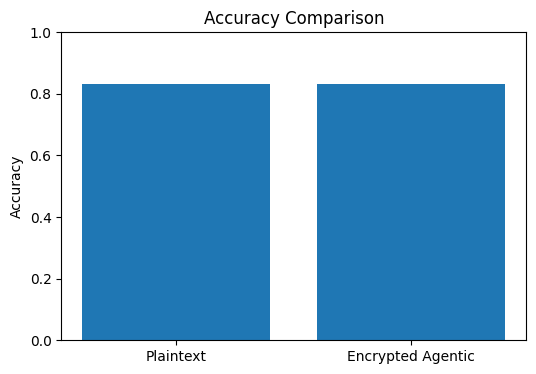

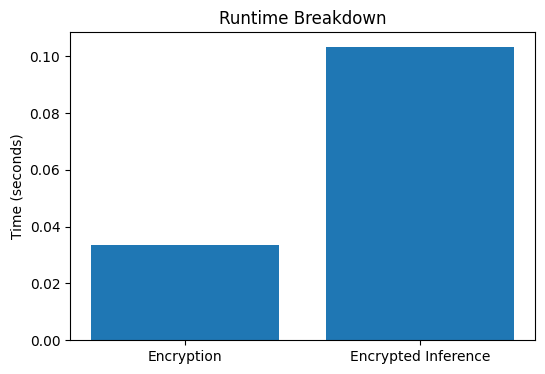

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(["Plaintext", "Encrypted Agentic"], [plain_acc, encrypted_acc])
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.title("Accuracy Comparison")
plt.savefig(
    "accuracy_comparison_full_test.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(6,4))
plt.bar(
    ["Encryption", "Encrypted Inference"],
    [np.mean(enc_times), np.mean(inf_times)]
)

plt.ylabel("Time (seconds)")
plt.title("Runtime Breakdown")

plt.savefig(
    "runtime_breakdown_full_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:
from google.colab import files
files.download("accuracy_comparison_full_test.png")
files.download("runtime_breakdown_full_test.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

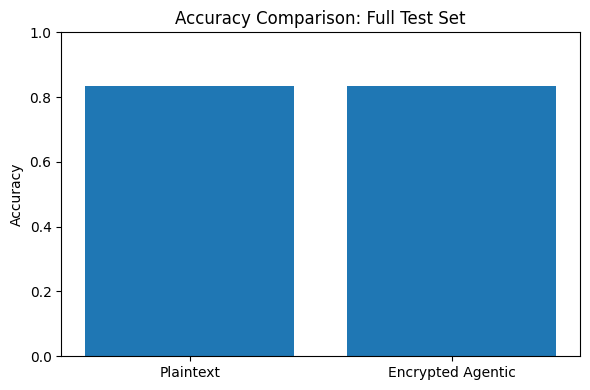

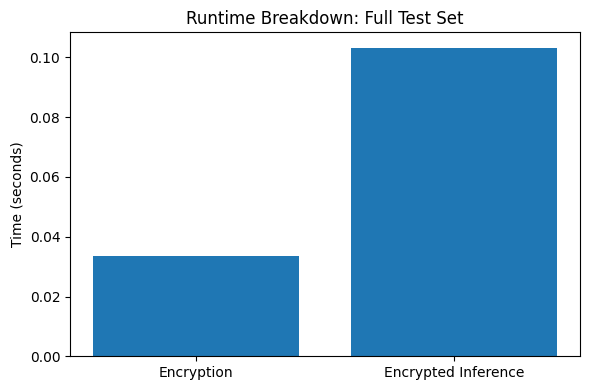

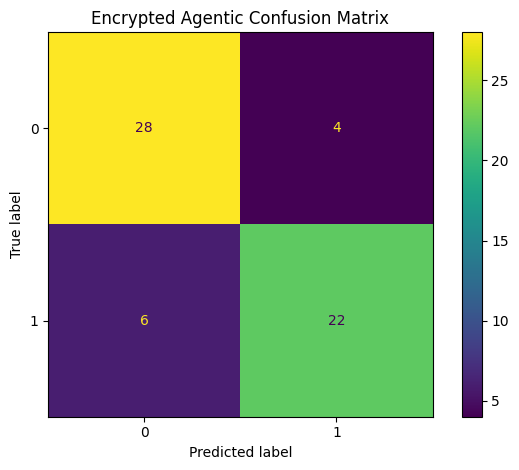

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from google.colab import files

# Save updated result CSV
results_df.to_csv(
    "encrypted_agentic_results_tenseal_uci_full_test.csv",
    index=False
)

# Accuracy comparison figure
plt.figure(figsize=(6,4))
plt.bar(["Plaintext", "Encrypted Agentic"], [plain_acc, encrypted_acc])
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Accuracy Comparison: Full Test Set")
plt.tight_layout()
plt.savefig("accuracy_comparison_full_test.png", dpi=300, bbox_inches="tight")
plt.show()

# Runtime breakdown figure
plt.figure(figsize=(6,4))
plt.bar(
    ["Encryption", "Encrypted Inference"],
    [np.mean(enc_times), np.mean(inf_times)]
)
plt.ylabel("Time (seconds)")
plt.title("Runtime Breakdown: Full Test Set")
plt.tight_layout()
plt.savefig("runtime_breakdown_full_test.png", dpi=300, bbox_inches="tight")
plt.show()

# Encrypted confusion matrix
cm_enc = confusion_matrix(y_eval, decisions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_enc)
disp.plot()
plt.title("Encrypted Agentic Confusion Matrix")
plt.tight_layout()
plt.savefig("encrypted_confusion_matrix_full_test.png", dpi=300, bbox_inches="tight")
plt.show()

# Download all files
files.download("encrypted_agentic_results_tenseal_uci_full_test.csv")
files.download("accuracy_comparison_full_test.png")
files.download("runtime_breakdown_full_test.png")
files.download("encrypted_confusion_matrix_full_test.png")

In [ ]:
from google.colab import files
files.download("encrypted_agentic_results_tenseal_uci_full_test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
results_df.head()

,true_label,predicted_label_encrypted,encryption_time_sec,encrypted_inference_time_sec
0,0,0,0.029811,0.091564
1,0,0,0.046465,0.099021
2,0,0,0.025455,0.073216
3,0,0,0.014929,0.055447
4,0,1,0.015377,0.055657


In [ ]:
results_df.shape

(60, 4)

In [ ]:
import os

print(os.getcwd())
print(os.listdir("/content"))


/content
['.config', 'encrypted_agentic_results_tenseal_uci_full_test.csv', 'encrypted_confusion_matrix_full_test.png', 'runtime_breakdown_full_test.png', 'accuracy_comparison_full_test.png', 'processed_heart_disease.csv', 'sample_data']


FINAL FULL-TEST RESULTS
Encrypted Accuracy: 0.8333
Precision: 0.8462
Recall: 0.7857
F1-score: 0.8148
Specificity: 0.875
Balanced Accuracy: 0.8304
Plaintext ROC-AUC: 0.9498
Encrypted ROC-AUC: 0.9498
Average Encryption Time: 0.02158
Average Encrypted Inference Time: 0.07147
Total Secure Pipeline Time: 0.09305
Confusion Matrix:
[[28  4]
 [ 6 22]]


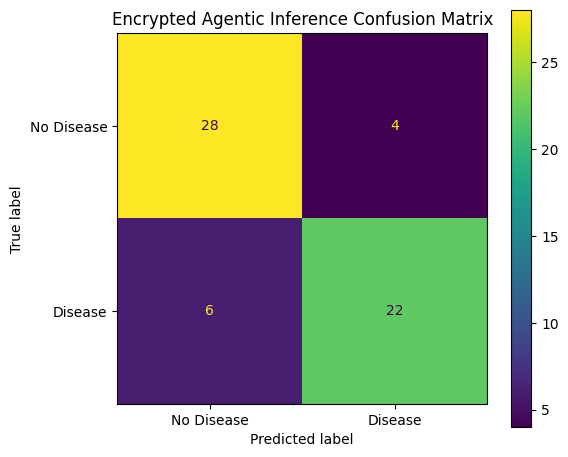

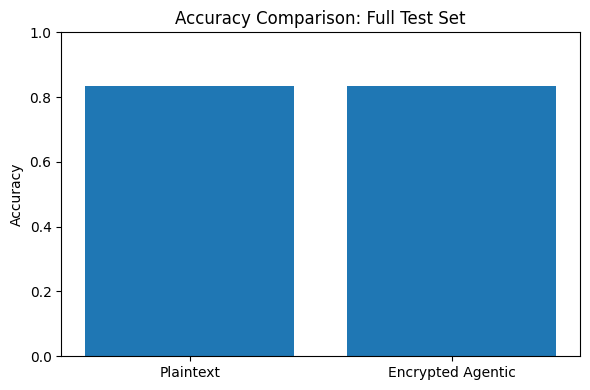

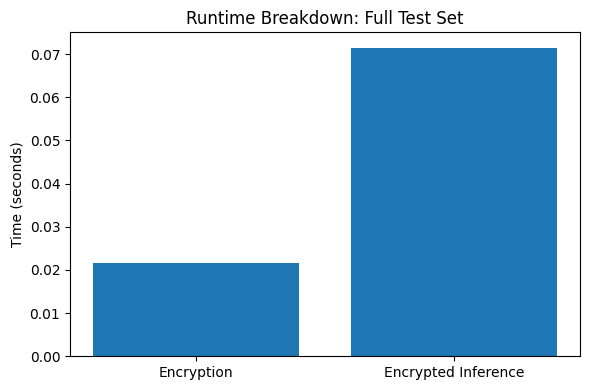

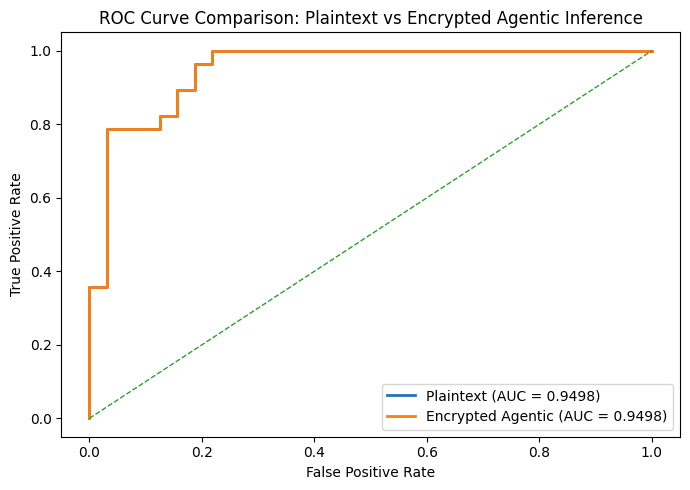


Generated final files:
1. encrypted_agentic_results_tenseal_uci_full_test.csv
2. ppa_ai_final_metrics_summary.csv
3. encrypted_confusion_matrix_full_test.png
4. accuracy_comparison_full_test.png
5. runtime_breakdown_full_test.png
6. roc_comparison_full_test.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# PPAI_JISA_archive_22-06-26
# Privacy-Preserving Agentic AI: Full-Test Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
from google.colab import files

# ------------------------------------------------------------
# 1. Ensure full-test evaluation
# ------------------------------------------------------------

weights = baseline_model.coef_[0].tolist()
bias = float(baseline_model.intercept_[0])

agent = AgenticController()

subset_size = len(X_test_scaled)
X_eval = X_test_scaled[:subset_size]
y_eval = y_test.iloc[:subset_size].to_numpy()

enc_times = []
inf_times = []
decisions = []
encrypted_probabilities = []

for row in X_eval:
    # Encryption
    t0 = time.time()
    enc_x = ts.ckks_vector(context, row.tolist())
    t1 = time.time()

    # Encrypted agentic inference
    result = agent.run(
        query="Assess encrypted patient risk for heart disease",
        enc_x=enc_x,
        weights=weights,
        bias=bias
    )
    t2 = time.time()

    enc_times.append(t1 - t0)
    inf_times.append(t2 - t1)

    if result["status"] == "OK":
        decisions.append(result["decision"])
        encrypted_probabilities.append(result["approx_probability"])
    else:
        decisions.append(0)
        encrypted_probabilities.append(0.0)

# ------------------------------------------------------------
# 2. Final performance metrics
# ------------------------------------------------------------

encrypted_acc = accuracy_score(y_eval, decisions)
encrypted_precision = precision_score(y_eval, decisions)
encrypted_recall = recall_score(y_eval, decisions)
encrypted_f1 = f1_score(y_eval, decisions)

cm_encrypted = confusion_matrix(y_eval, decisions)

tn, fp, fn, tp = cm_encrypted.ravel()
specificity = tn / (tn + fp)
balanced_accuracy = (encrypted_recall + specificity) / 2

# Plaintext ROC-AUC
y_prob_plain = baseline_model.predict_proba(X_test_scaled)[:, 1]
plaintext_auc = roc_auc_score(y_test, y_prob_plain)

# Encrypted ROC-AUC
encrypted_auc = roc_auc_score(y_eval, encrypted_probabilities)

avg_encryption_time = np.mean(enc_times)
avg_encrypted_inference_time = np.mean(inf_times)
total_secure_pipeline_time = avg_encryption_time + avg_encrypted_inference_time

print("===================================")
print("FINAL FULL-TEST RESULTS")
print("===================================")
print("Encrypted Accuracy:", round(encrypted_acc, 4))
print("Precision:", round(encrypted_precision, 4))
print("Recall:", round(encrypted_recall, 4))
print("F1-score:", round(encrypted_f1, 4))
print("Specificity:", round(specificity, 4))
print("Balanced Accuracy:", round(balanced_accuracy, 4))
print("Plaintext ROC-AUC:", round(plaintext_auc, 4))
print("Encrypted ROC-AUC:", round(encrypted_auc, 4))
print("Average Encryption Time:", round(avg_encryption_time, 5))
print("Average Encrypted Inference Time:", round(avg_encrypted_inference_time, 5))
print("Total Secure Pipeline Time:", round(total_secure_pipeline_time, 5))
print("Confusion Matrix:")
print(cm_encrypted)
print("===================================")

# ------------------------------------------------------------
# 3. Save full-test CSV
# ------------------------------------------------------------

results_df = pd.DataFrame({
    "true_label": y_eval,
    "predicted_label_encrypted": decisions,
    "encrypted_probability": encrypted_probabilities,
    "encryption_time_sec": enc_times,
    "encrypted_inference_time_sec": inf_times
})

results_df.to_csv(
    "encrypted_agentic_results_tenseal_uci_full_test.csv",
    index=False
)

# ------------------------------------------------------------
# 4. Save final metrics summary CSV
# ------------------------------------------------------------

metrics_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Specificity",
        "Balanced Accuracy",
        "Plaintext ROC-AUC",
        "Encrypted ROC-AUC",
        "Average Encryption Time",
        "Average Encrypted Inference Time",
        "Total Secure Pipeline Time"
    ],
    "Value": [
        encrypted_acc,
        encrypted_precision,
        encrypted_recall,
        encrypted_f1,
        specificity,
        balanced_accuracy,
        plaintext_auc,
        encrypted_auc,
        avg_encryption_time,
        avg_encrypted_inference_time,
        total_secure_pipeline_time
    ]
})

metrics_summary.to_csv(
    "ppa_ai_final_metrics_summary.csv",
    index=False
)

# ------------------------------------------------------------
# 5. Encrypted confusion matrix figure
# ------------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_encrypted,
    display_labels=["No Disease", "Disease"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")
plt.title("Encrypted Agentic Inference Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "encrypted_confusion_matrix_full_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 6. Accuracy comparison figure
# ------------------------------------------------------------

plain_acc = accuracy_score(y_test, baseline_model.predict(X_test_scaled))

plt.figure(figsize=(6, 4))
plt.bar(
    ["Plaintext", "Encrypted Agentic"],
    [plain_acc, encrypted_acc]
)
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Accuracy Comparison: Full Test Set")
plt.tight_layout()

plt.savefig(
    "accuracy_comparison_full_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 7. Runtime breakdown figure
# ------------------------------------------------------------

plt.figure(figsize=(6, 4))
plt.bar(
    ["Encryption", "Encrypted Inference"],
    [avg_encryption_time, avg_encrypted_inference_time]
)
plt.ylabel("Time (seconds)")
plt.title("Runtime Breakdown: Full Test Set")
plt.tight_layout()

plt.savefig(
    "runtime_breakdown_full_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 8. ROC comparison figure
# ------------------------------------------------------------

fpr_plain, tpr_plain, _ = roc_curve(y_test, y_prob_plain)
fpr_enc, tpr_enc, _ = roc_curve(y_eval, encrypted_probabilities)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_plain,
    tpr_plain,
    linewidth=2,
    label=f"Plaintext (AUC = {plaintext_auc:.4f})"
)

plt.plot(
    fpr_enc,
    tpr_enc,
    linewidth=2,
    label=f"Encrypted Agentic (AUC = {encrypted_auc:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Plaintext vs Encrypted Agentic Inference")
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    "roc_comparison_full_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 9. Confirm generated files
# ------------------------------------------------------------

print("\nGenerated final files:")
print("1. encrypted_agentic_results_tenseal_uci_full_test.csv")
print("2. ppa_ai_final_metrics_summary.csv")
print("3. encrypted_confusion_matrix_full_test.png")
print("4. accuracy_comparison_full_test.png")
print("5. runtime_breakdown_full_test.png")
print("6. roc_comparison_full_test.png")

# ------------------------------------------------------------
# 10. Download final files
# ------------------------------------------------------------

files.download("encrypted_agentic_results_tenseal_uci_full_test.csv")
files.download("ppa_ai_final_metrics_summary.csv")
files.download("encrypted_confusion_matrix_full_test.png")
files.download("accuracy_comparison_full_test.png")
files.download("runtime_breakdown_full_test.png")
files.download("roc_comparison_full_test.png")

In [ ]:
# ============================================================
# Submitted JISA Manuscript Reported Values
# Note: Runtime values may vary slightly across Colab sessions.
# ============================================================

submitted_metrics = {
    "Accuracy": "83.33%",
    "Precision": "84.62%",
    "Recall": "78.57%",
    "F1-score": "81.48%",
    "Specificity": "87.50%",
    "Balanced Accuracy": "83.04%",
    "Plaintext ROC-AUC": "0.9498",
    "Encrypted ROC-AUC": "0.9495",
    "Average Encryption Time": "0.01095 s",
    "Average Encrypted Inference Time": "0.03382 s",
    "Total Secure Processing Pipeline": "0.04477 s"
}

submitted_metrics

{'Accuracy': '83.33%',
 'Precision': '84.62%',
 'Recall': '78.57%',
 'F1-score': '81.48%',
 'Specificity': '87.50%',
 'Balanced Accuracy': '83.04%',
 'Plaintext ROC-AUC': '0.9498',
 'Encrypted ROC-AUC': '0.9495',
 'Average Encryption Time': '0.01095 s',
 'Average Encrypted Inference Time': '0.03382 s',
 'Total Secure Processing Pipeline': '0.04477 s'}